In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("C:/Users/EfrenMariscal/Documents/data scientific/kaggle/heartAttack/Medicaldataset.csv")
df.head(10)
#1 hombre, 0 mujer

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
5,58,0,61,112,58,87.0,1.83,0.004,negative
6,32,0,40,179,68,102.0,0.71,0.003,negative
7,63,1,60,214,82,87.0,300.00,2.370,positive
8,44,0,60,154,81,135.0,2.35,0.004,negative
9,67,1,61,160,95,100.0,2.84,0.011,negative


In [4]:
df.loc[df["Heart rate"]==1111,"Heart rate"] = 0
promedio = df["Heart rate"].mean()
df.loc[df["Heart rate"]==0,"Heart rate"] = int(promedio)
maximo = df.sort_values(by=["Heart rate"],ascending=False)
maximo

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
1012,65,1,135,98,60,162.0,7.67,0.025,positive
682,68,1,135,98,60,96.0,254.40,0.025,positive
21,48,1,135,98,60,100.0,94.79,0.004,positive
346,60,1,134,111,69,163.0,3.08,0.025,positive
1213,76,1,134,111,69,92.0,2.37,0.031,positive
...,...,...,...,...,...,...,...,...,...
1313,86,0,40,179,68,147.0,5.22,0.011,negative
666,53,1,40,179,68,197.0,2.37,3.210,positive
1024,65,1,36,106,58,88.0,1.25,0.088,positive
1060,63,0,20,110,90,122.0,0.68,1.510,positive


In [5]:
df.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,75.980288,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,15.259552,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,135.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [6]:
#Anlizando si el df contiene valores nulos
df.isnull().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

## Categorizando las variables del dataset
**Age:** Variable cuantitativa continua\
**Gender:** Variable cualitativa nominal\
**Heart rate:** Variable cuantitativa continua\
**Systolic blood pressure:** Variable cuantitativa continua\
**Diastolic blood pressure:** Variable cuantitativa continua\
**Blood sugar:** Variable cuantitativa discreta\
**CK-MB:** Variable cuantitativa discreta\
**Troponin:** Variable cuantitativa discreta

In [7]:
#DESCRIPCION GENERAL DE LAS VARIABLES
print(df.Result.value_counts())
print("")
print(df.Age.value_counts().head(15))
print("")
print(df["Heart rate"].value_counts())

Result
positive    810
negative    509
Name: count, dtype: int64

Age
60    106
70     73
50     68
63     64
65     62
55     60
45     42
58     34
68     31
75     29
52     28
47     28
53     27
62     27
48     26
Name: count, dtype: int64

Heart rate
60     95
61     57
70     48
64     47
82     46
       ..
99      1
114     1
122     1
110     1
45      1
Name: count, Length: 78, dtype: int64


In [8]:
#rango de datos
puntos_corte=[40,50,60,70]
etiquetas= ["40-50","50-60","60-70"]
corte = pd.cut(x=df.Age,bins=puntos_corte,labels=etiquetas)
magnitud=corte.value_counts().sort_index()
ms=pd.Series(magnitud.index)

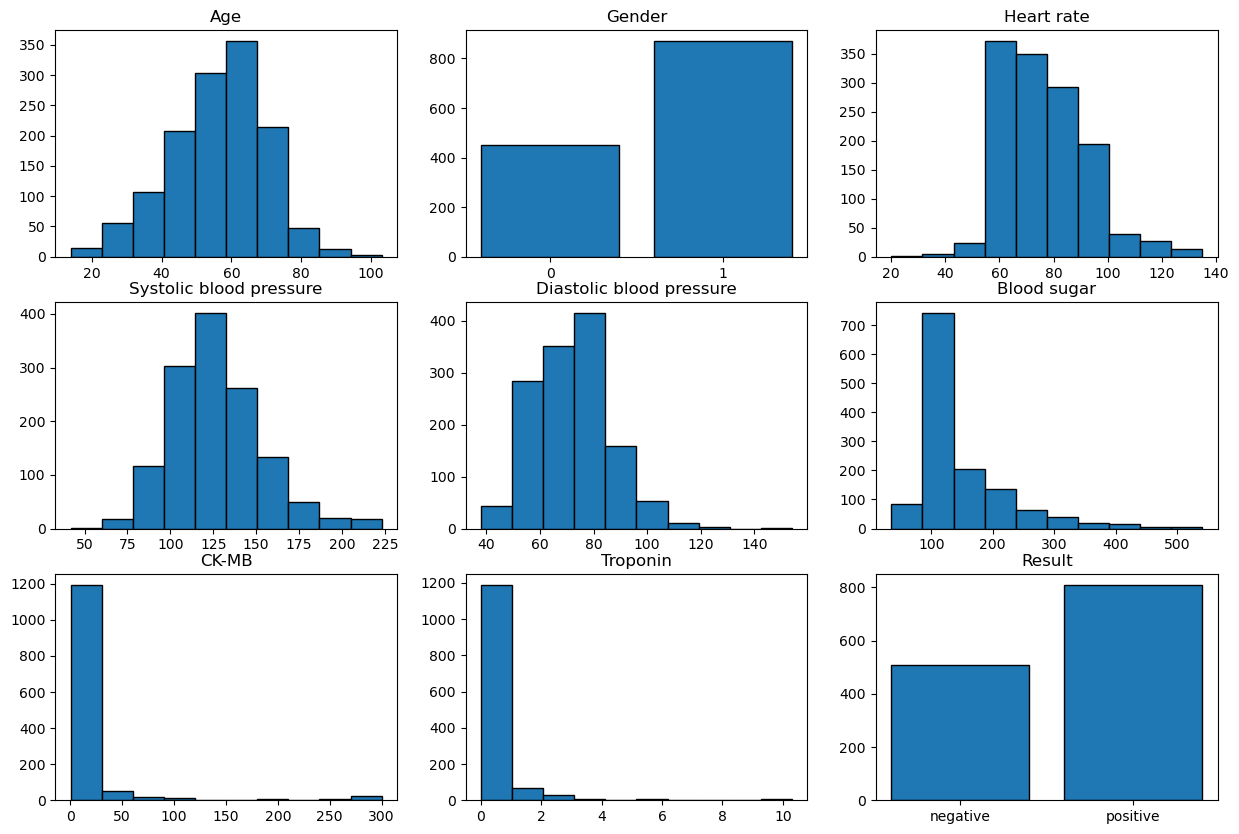

In [9]:
fig,ax=plt.subplots(nrows=3,ncols=3,figsize=(15,10))
ax1=ax[0,0]
ax2=ax[0,1]
ax3=ax[0,2]
ax4=ax[1,0]
ax5=ax[1,1]
ax6=ax[1,2]
ax7=ax[2,0]
ax8=ax[2,1]
ax9=ax[2,2]

ax1.set_title("Age")
ax1.hist(df.Age,edgecolor="Black")

ax2.set_title("Gender")
genero=df.Gender.value_counts().sort_index()
ax2.bar(genero.index,genero.values,edgecolor="Black")
ax2.set_xticks(genero.index,genero.index)

ax3.set_title("Heart rate")
ax3.hist(df["Heart rate"],edgecolor="Black")

ax4.set_title("Systolic blood pressure")
ax4.hist(df["Systolic blood pressure"],edgecolor="Black")

ax5.set_title("Diastolic blood pressure")
ax5.hist(df["Diastolic blood pressure"],edgecolor="Black")

ax6.set_title("Blood sugar")
ax6.hist(df["Blood sugar"],edgecolor="Black")

ax7.set_title("CK-MB")
ax7.hist(df["CK-MB"],edgecolor="Black")

ax8.set_title("Troponin")
ax8.hist(df["Troponin"],edgecolor="Black")

ax9.set_title("Result")
resultado=df["Result"].value_counts().sort_index()
ax9.bar(resultado.index,resultado.values,edgecolor="Black");

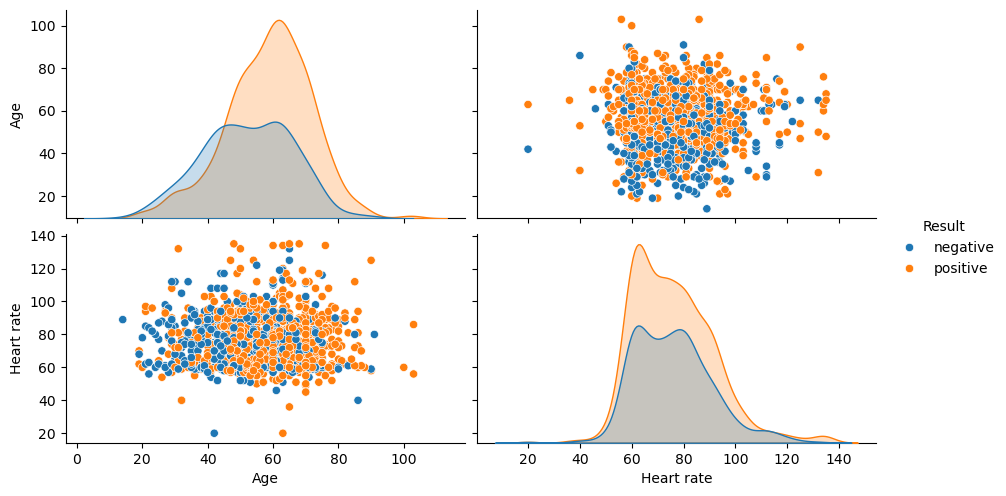

In [10]:
df_pair = df.loc[:,["Age","Heart rate","Result"]]  
sns.pairplot(df_pair,hue="Result",height=2.5, aspect=1.8);

Text(0.5, 1.0, 'Result vs CK-MB')

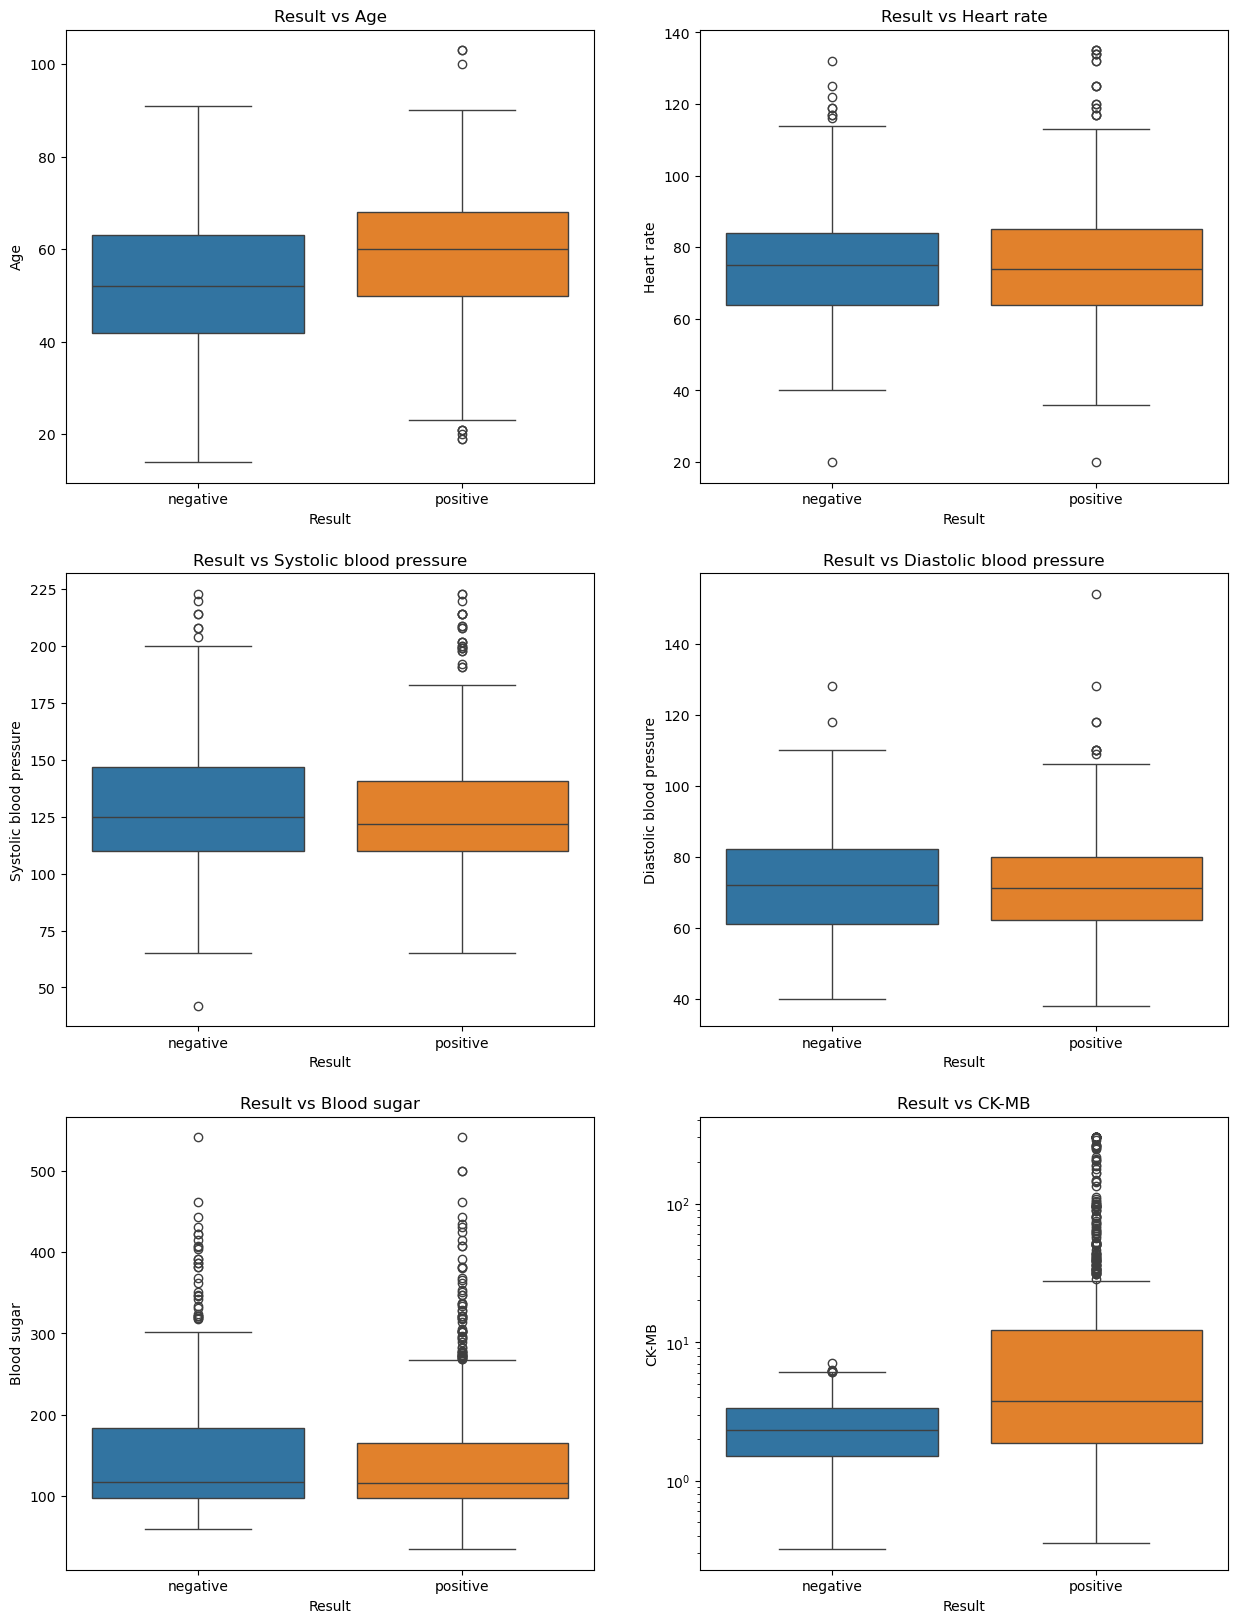

In [16]:
fig,ax=plt.subplots(nrows=3,ncols=2,figsize=(15,20))
ax1=ax[0,0]
ax2=ax[0,1]
ax3=ax[1,0]
ax4=ax[1,1]
ax5=ax[2,0]
ax6=ax[2,1]
#ax7=ax[3,0]
sns.boxplot(data=df,x="Result",y="Age",hue="Result",ax=ax1)
ax1.set_title("Result vs Age")

sns.boxplot(data=df,x="Result",y="Heart rate",hue="Result",ax=ax2)
ax2.set_title("Result vs Heart rate")

sns.boxplot(data=df,x="Result",y="Systolic blood pressure",hue="Result",ax=ax3)
ax3.set_title("Result vs Systolic blood pressure")

sns.boxplot(data=df,x="Result",y="Diastolic blood pressure",hue="Result",ax=ax4)
ax4.set_title("Result vs Diastolic blood pressure")

sns.boxplot(data=df,x="Result",y="Blood sugar",hue="Result",ax=ax5)
ax5.set_title("Result vs Blood sugar")

sns.boxplot(data=df,x="Result",y="CK-MB",hue="Result",ax=ax6)
plt.yscale('log')
ax6.set_title("Result vs CK-MB")

#ax7.set_title("Troponin")
#sns.boxplot(data=df,x="Result",y="Troponin",ax=ax7)
#plt.yscale("log");

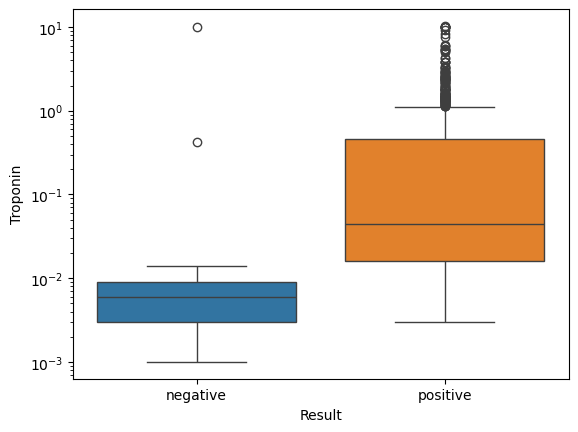

In [17]:
sns.boxplot(data=df,x="Result",y="Troponin",hue="Result");
plt.yscale("log")

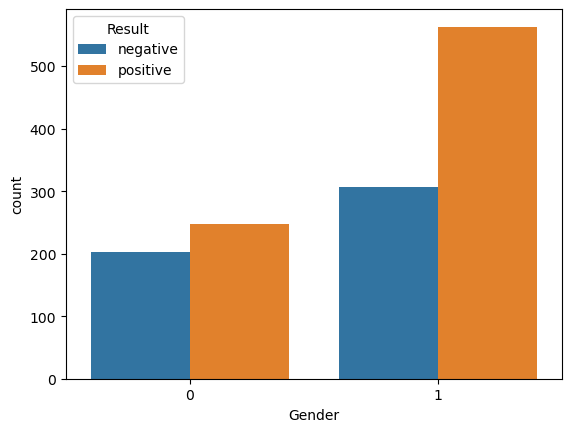

In [30]:
sns.countplot(data=df,x="Gender",hue="Result");

In [35]:

features = ["Age","Heart rate","Systolic blood pressure","Diastolic blood pressure","Blood sugar","CK-MB","Troponin"] 
X = df[features].fillna(df[features].median()) 
y = df['Result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(f"Precisión: {accuracy_score(y_test, y_pred)}")
print("")

Precisión: 0.9734848484848485



In [36]:
X_columnas = X_train.columns
importancia_var = rf_model.feature_importances_
df_importancia = pd.DataFrame({"variable":X_columnas,"importancia":importancia_var})
df_importancia = df_importancia.sort_values(by="importancia",ascending=False)
df_importancia

,variable,importancia
6,Troponin,0.606432
5,CK-MB,0.270830
0,Age,0.046890
4,Blood sugar,0.024055
2,Systolic blood pressure,0.020480
3,Diastolic blood pressure,0.017024
1,Heart rate,0.014290
